# Intensity Transformations & Filtering Spatial Domain

## Thresholding

Threshold value: 0


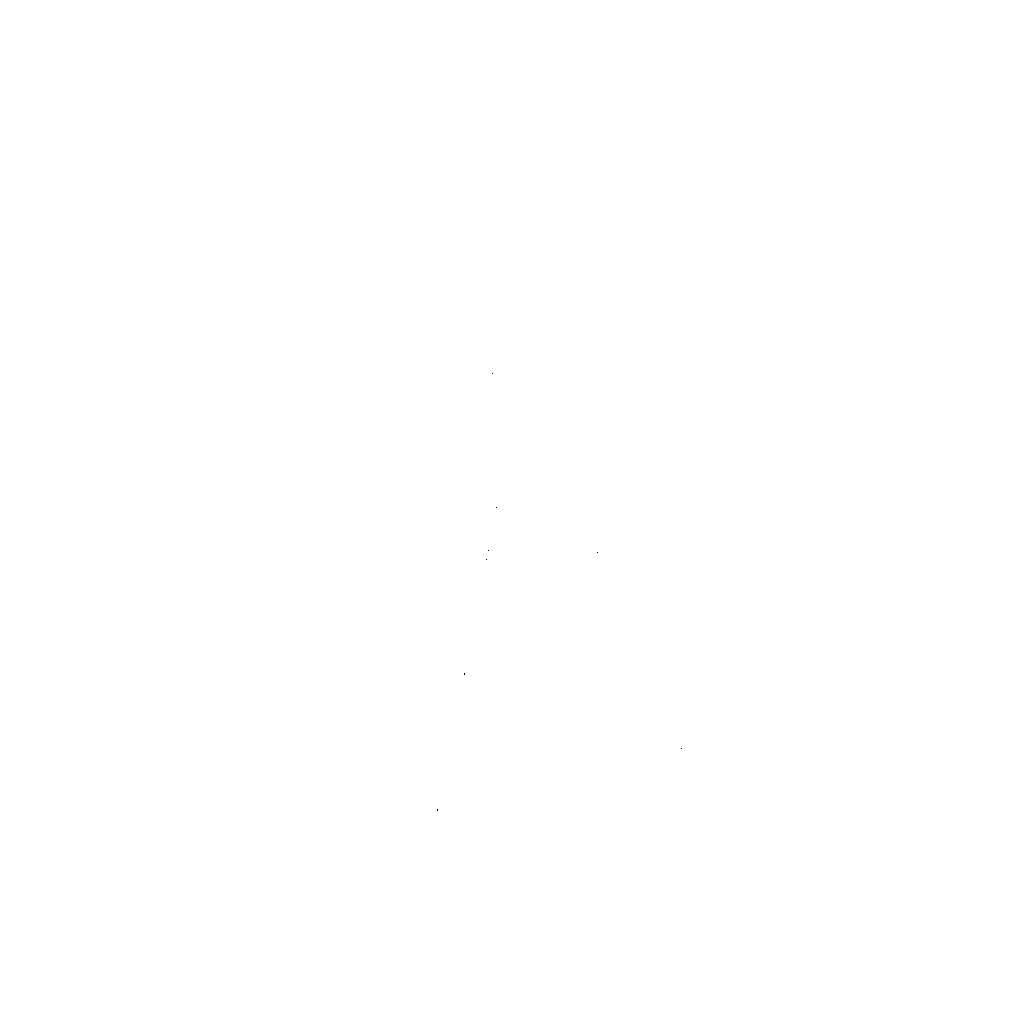

Threshold value: 50


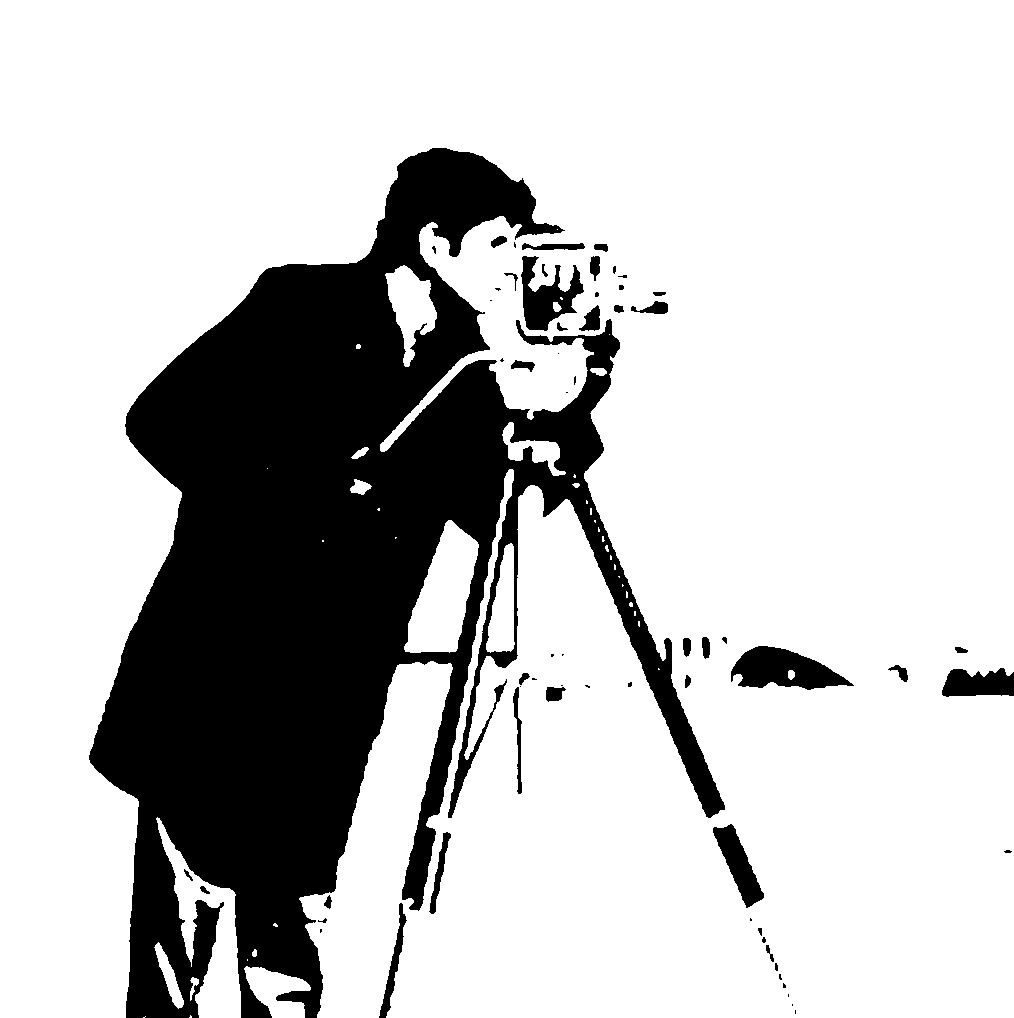

Threshold value: 100


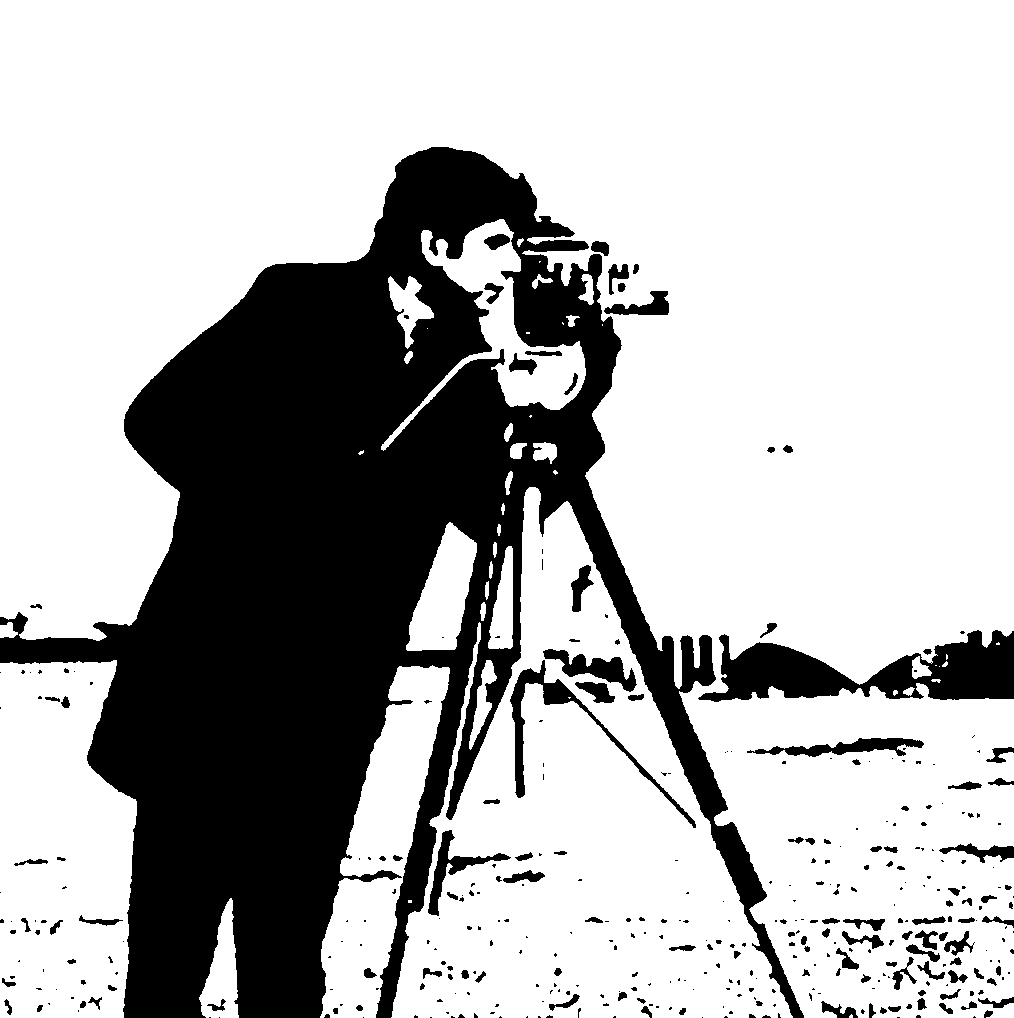

Threshold value: 150


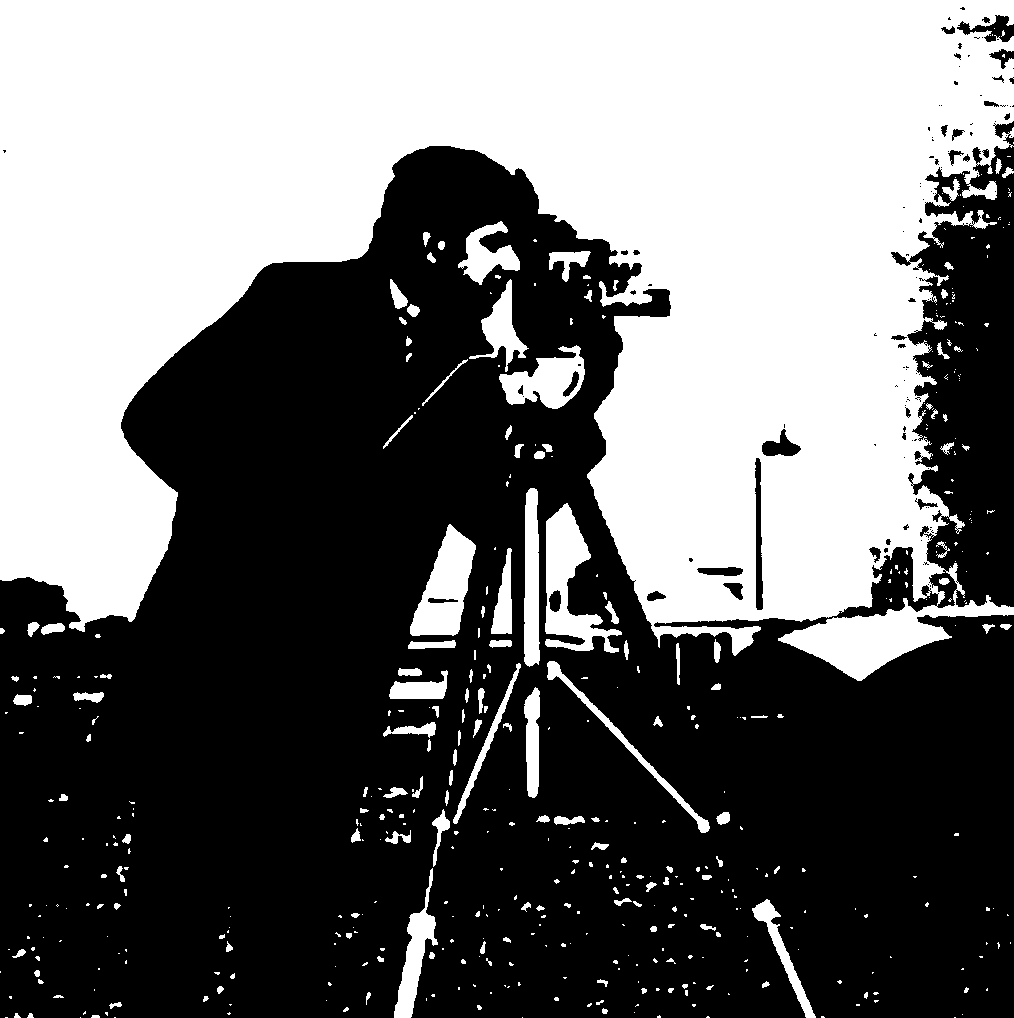

Threshold value: 200


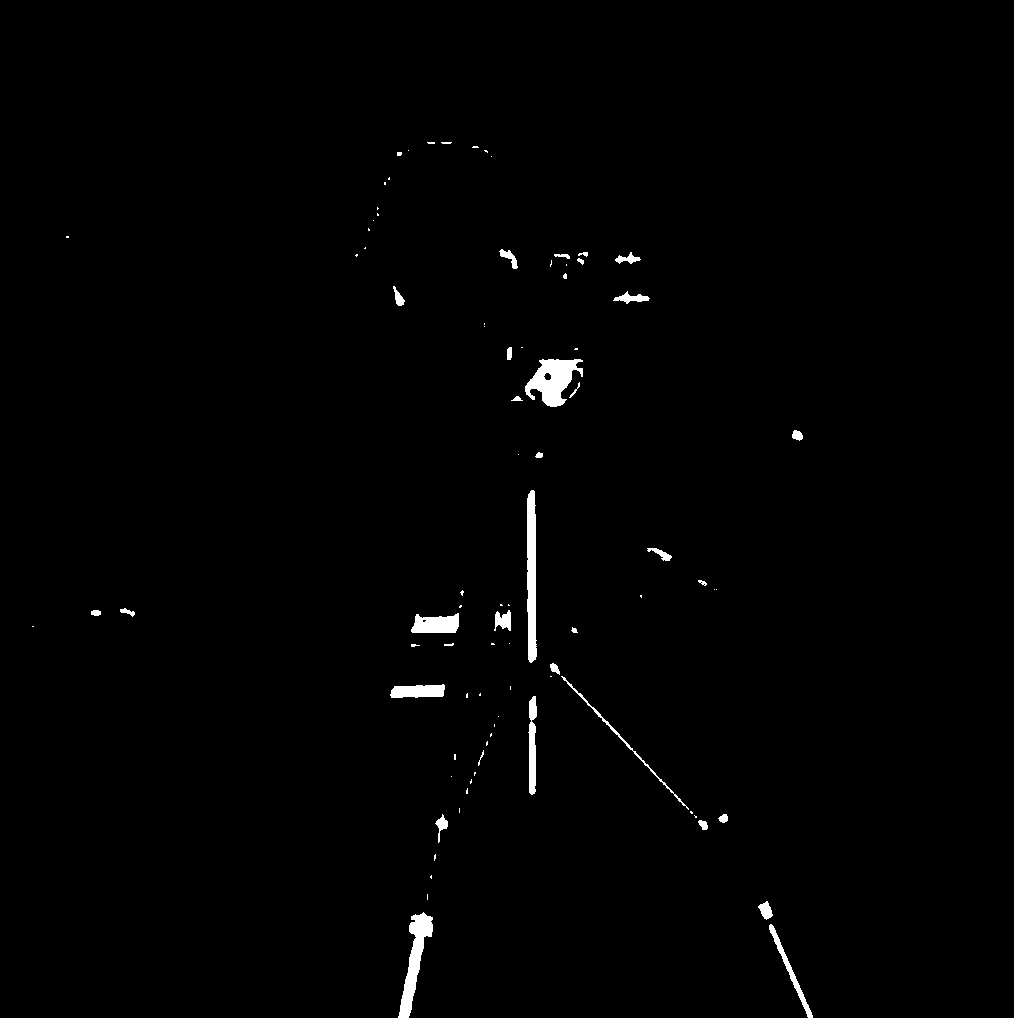

In [14]:
import cv2
from google.colab.patches import cv2_imshow

# Load the image in grayscale
img = cv2.imread('cameraman.png', cv2.IMREAD_GRAYSCALE) # GRAYSCALE يحولها لاسود وابيض

# Set the threshold values
threshold_values = [0, 50, 100, 150, 200]

# Apply thresholding with different threshold values اقارن كل القيم بالثريشولد وعلى اساسه احط الالوان  مثلا قيمه اكبر 150  تصير ابيض والعكس تصير بلاك
for threshold_value in threshold_values:
    ret_thresh_value, thresh_img = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY) # وايت
# يرجع وش القيمه اللي رجعت
    print(f"Threshold value: {threshold_value}")
    cv2_imshow(thresh_img)
    #اول اوتبوت يكون ابيض  لانه صفر


Original Image: 


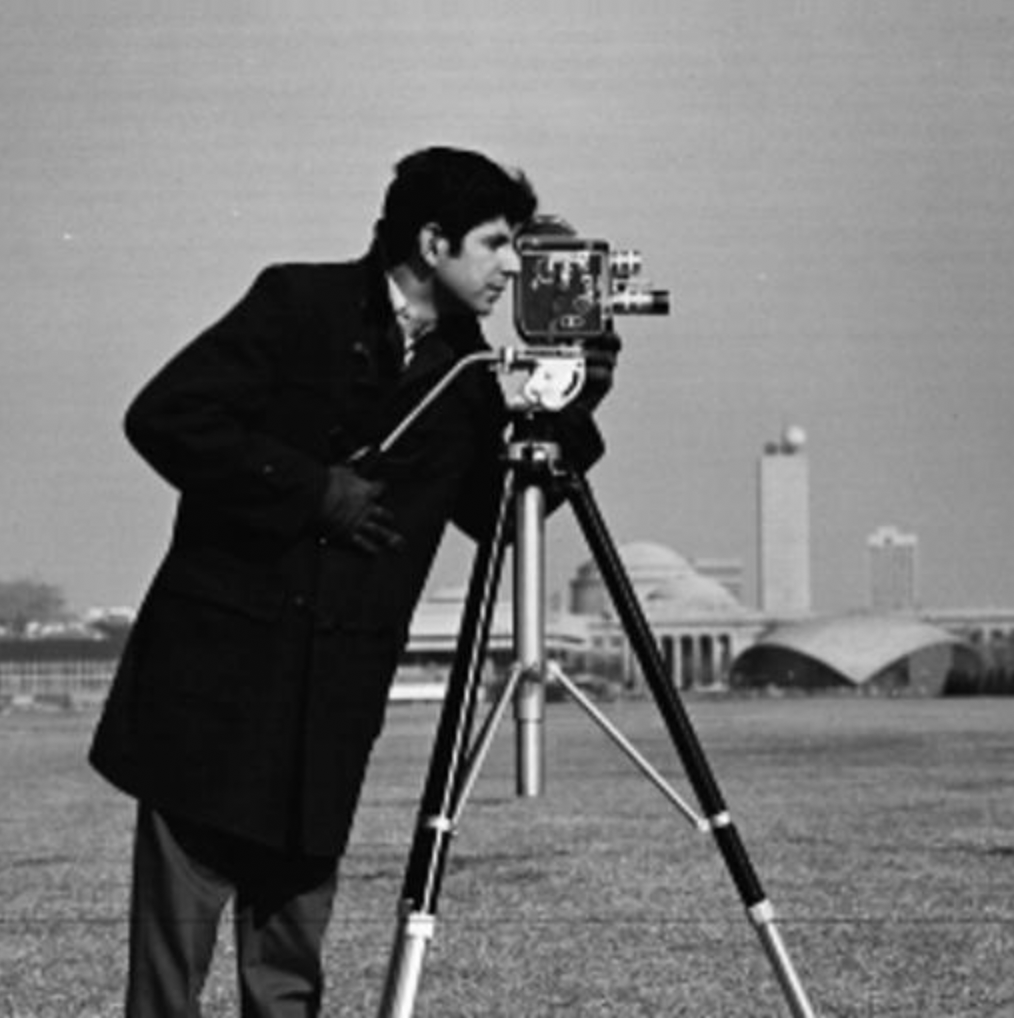

In [ ]:
print("Original Image: ")
cv2_imshow(img)

## Histograms

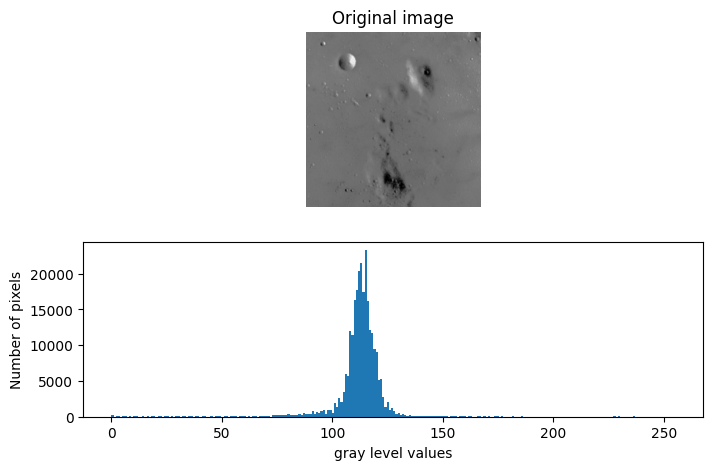

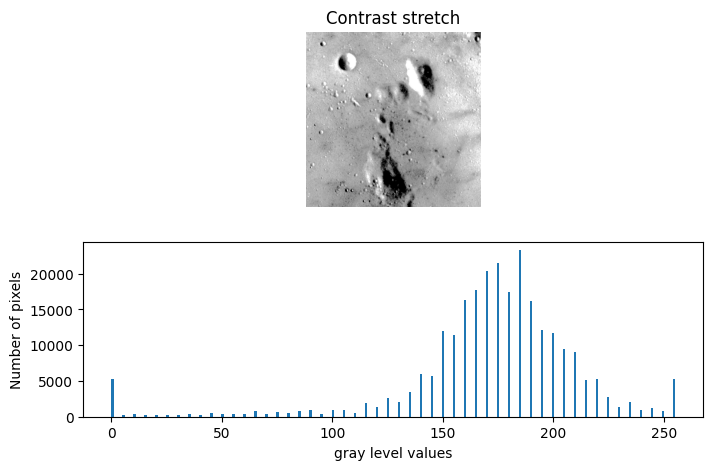

In [ ]:
# Task#2: Histogram Processing

# Step#1: Load necessary libraries
import matplotlib # hmport for image
import matplotlib.pyplot as plt
import numpy as np

from skimage import data   #image جاهزه
from skimage import exposure

# Step#2: Load moon image
img = data.moon()

# Step#3: Rescale intensity values to include all the intensities that fall within the 2nd and 98th percentiles
# Contrast stretching :  يحسن جودة الصوره وتشبه الثريشولدينق
#يقلص لي الرينج عشان يحسن الصوره ويبعد عني الاوتلابر
p2, p98 = np.percentile(img, (2, 98)) #احول الصوره للبرسنتايل
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98)) # rescale_intensity هي الي تسوي كونستراكت سترتشينق

# Step#4: Display the image with its histogram of (step#2)  and (step#3)
fig = plt.figure(figsize=(8, 5)) #size
fig.add_subplot(2, 1, 1) # 2 row , 1 colom , put it in position 1
plt.imshow(img, cmap = 'gray')
plt.axis('off')
plt.title('Original image')

fig.add_subplot(2, 1, 2)# 2 row , 1 colom , put it in position 2
plt.hist(img.flat, bins = 256, range=(0, 255)) # تستقببلها بعد ماسوي فلاتينق
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap = 'gray')
plt.axis('off')
plt.title('Contrast stretch')

fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

# Tasks:

Task1: Using the same ‘moon image’ Rescale intensity values to include all the intensities that fall within the 3nd and 80th percentiles, and plot the histogram

Task2: Using the same ‘moon image’ and the exposure.equalize_hist function, display the image and the histogram of the image after flattening the histogram.

Task3: Use the rocket (as reference) and chelsea images (from skimage.data) and implement histogram matching


In [6]:
from skimage import data, exposure
import numpy as np
import matplotlib.pyplot as plt

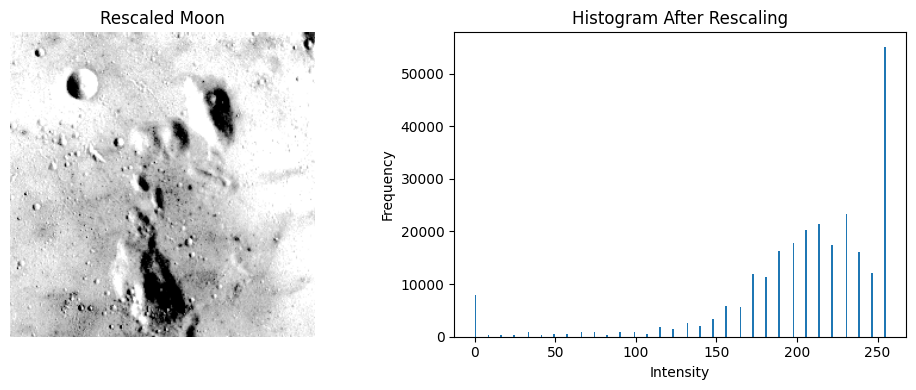

3rd percentile: 87.0
80th percentile: 118.0


In [15]:
moon = data.moon()
p3, p80 = np.percentile(moon, (3, 80))

rescaled_moon = exposure.rescale_intensity(
    moon,
    in_range=(p3, p80),
    out_range=(0, 255)
)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(rescaled_moon, cmap='gray')
plt.title("Rescaled Moon")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.hist(rescaled_moon.ravel(), bins=256)
plt.title("Histogram After Rescaling")
plt.xlabel("Intensity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

print("3rd percentile:", p3)
print("80th percentile:", p80)

Task **2**

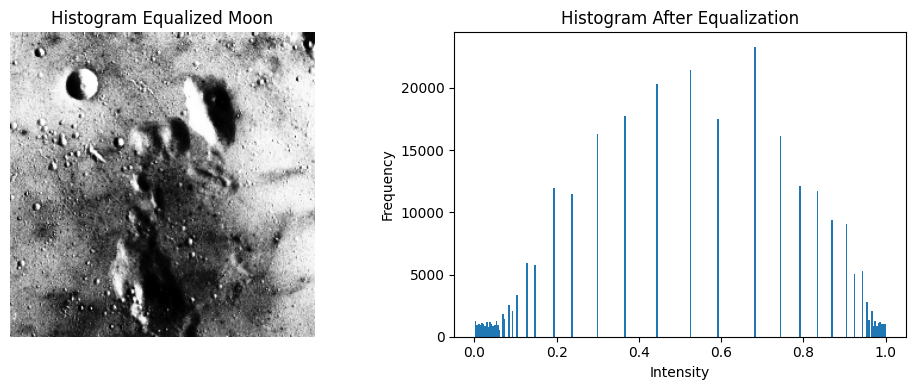

In [16]:

equalized_moon = exposure.equalize_hist(moon)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(equalized_moon, cmap='gray')
plt.title("Histogram Equalized Moon")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.hist(equalized_moon.ravel(), bins=256)
plt.title("Histogram After Equalization")
plt.xlabel("Intensity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

**Task3**

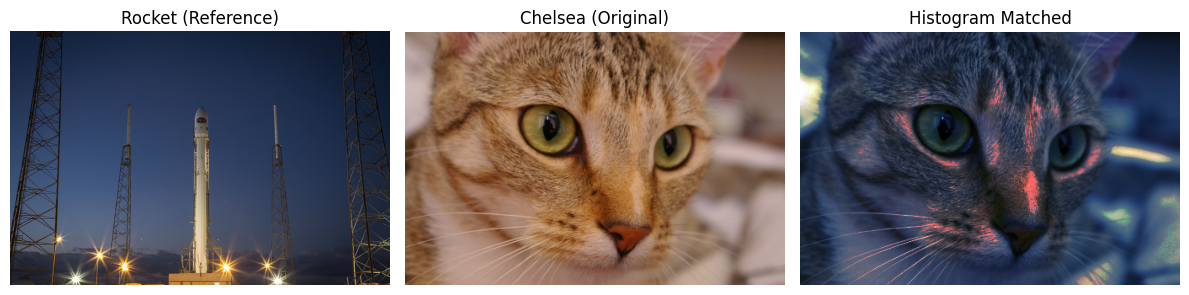

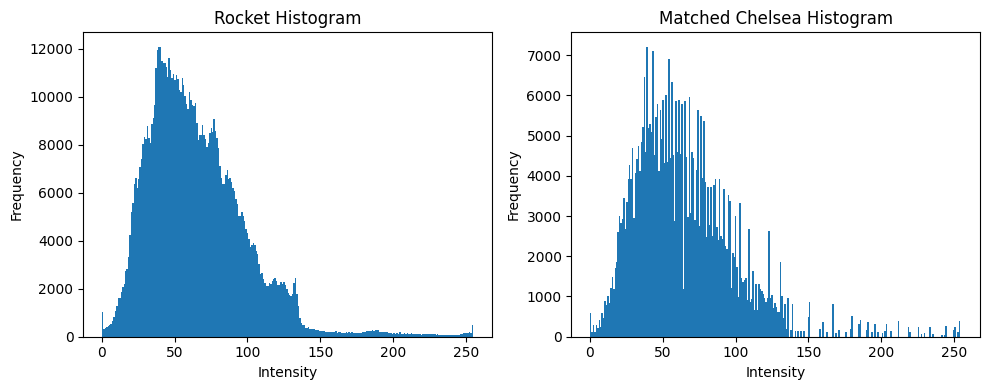

In [17]:

rocket = data.rocket()
chelsea = data.chelsea()

matched_chelsea = exposure.match_histograms(
    chelsea,
    rocket,
    channel_axis=-1
)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(rocket)
plt.title("Rocket (Reference)")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(chelsea)
plt.title("Chelsea (Original)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(matched_chelsea)
plt.title("Histogram Matched")
plt.axis("off")

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(rocket.ravel(), bins=256)
plt.title("Rocket Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(matched_chelsea.ravel(), bins=256)
plt.title("Matched Chelsea Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()